In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

In [ ]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Shape:", X.shape)
print("Classes:", data.target_names)
X.head()

Shape: (569, 30)
Classes: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
X.info()

print("\nMissing values:", X.isnull().sum().sum())
print("\nClass distribution:")
print(y.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

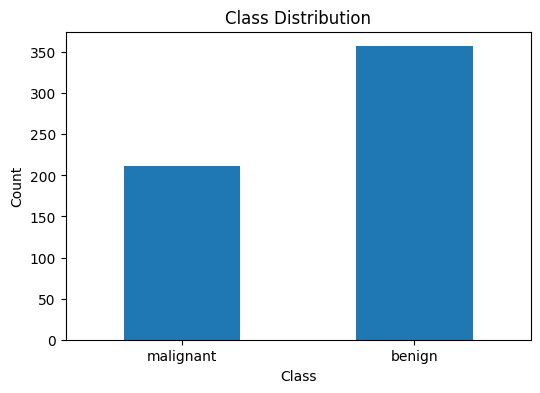

In [ ]:
plt.figure(figsize=(6,4))
y.value_counts().sort_index().plot(kind="bar")
plt.xticks([0,1], data.target_names, rotation=0)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 455
Testing samples: 114


In [ ]:
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    random_state=42
)

bag_params = {
    "n_estimators": [10, 50, 100],
    "max_samples": [0.5, 0.8, 1.0],
    "max_features": [0.5, 0.8, 1.0]
}

bag_grid = GridSearchCV(
    bag, bag_params, cv=5,
    scoring="accuracy", n_jobs=-1
)

bag_grid.fit(X_train, y_train)

bag_model = bag_grid.best_estimator_

print("Best parameters:", bag_grid.best_params_)
print("Best CV accuracy:", bag_grid.best_score_)

Best parameters: {'max_features': 0.5, 'max_samples': 0.8, 'n_estimators': 100}
Best CV accuracy: 0.9604395604395606


In [ ]:
bag_table = pd.DataFrame(bag_grid.cv_results_)

bag_table = bag_table[
    ["param_n_estimators", "param_max_samples", "param_max_features",
     "mean_test_score", "std_test_score"]
]

bag_table.columns = [
    "n_estimators", "max_samples", "max_features",
    "Avg CV Accuracy", "Std"
]

bag_table["Avg CV Accuracy"] = bag_table["Avg CV Accuracy"] * 100
bag_table = bag_table.sort_values("Avg CV Accuracy", ascending=False)

bag_table.head(10)

,n_estimators,max_samples,max_features,Avg CV Accuracy,Std
5,100,0.8,0.5,96.043956,0.014906
8,100,1.0,0.5,96.043956,0.016447
7,50,1.0,0.5,95.824176,0.010767
1,50,0.5,0.5,95.604396,0.018388
4,50,0.8,0.5,95.604396,0.012038
15,10,1.0,0.8,95.604396,0.025059
14,100,0.8,0.8,95.604396,0.019658
17,100,1.0,0.8,95.604396,0.018388
11,100,0.5,0.8,95.384615,0.016150
2,100,0.5,0.5,95.384615,0.014579


In [ ]:
bag_f1 = cross_validate(
    bag_model,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("Bagging Avg CV F1 Score:", bag_f1["test_score"].mean())

Bagging Avg CV F1 Score: 0.9685051350864112


In [ ]:
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    random_state=42
)

ada_params = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.01, 0.1, 1.0]
}

ada_grid = GridSearchCV(
    ada, ada_params, cv=5,
    scoring="accuracy", n_jobs=-1
)

ada_grid.fit(X_train, y_train)

ada_model = ada_grid.best_estimator_

print("Best parameters:", ada_grid.best_params_)
print("Best CV accuracy:", ada_grid.best_score_)

Best parameters: {'learning_rate': 1.0, 'n_estimators': 100}
Best CV accuracy: 0.9736263736263737


In [ ]:
ada_results = pd.DataFrame(ada_grid.cv_results_)

ada_results = ada_results[
    ["param_n_estimators", "param_learning_rate", "mean_test_score"]
]

ada_results.columns = [
    "n_estimators", "learning_rate", "Avg CV Accuracy"
]

ada_results["Avg CV Accuracy"] = ada_results["Avg CV Accuracy"] * 100

ada_f1_scores = []

for _, row in ada_results.iterrows():
    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
        n_estimators=int(row["n_estimators"]),
        learning_rate=float(row["learning_rate"]),
        random_state=42
    )
    scores = cross_validate(model, X_train, y_train, cv=5, scoring="f1")
    ada_f1_scores.append(scores["test_score"].mean() * 100)

ada_results["Avg CV F1 Score"] = ada_f1_scores

ada_results.sort_values("Avg CV Accuracy", ascending=False)

,n_estimators,learning_rate,Avg CV Accuracy,Avg CV F1 Score
7,100,1.00,97.362637,97.918961
8,150,1.00,97.362637,97.918961
6,50,1.00,96.923077,97.565138
5,150,0.10,96.483516,97.223283
4,100,0.10,96.263736,97.043163
3,50,0.10,96.043956,96.866328
1,100,0.01,93.406593,94.800211
0,50,0.01,93.186813,94.611536
2,150,0.01,92.967033,94.482475


In [ ]:
gb = GradientBoostingClassifier(random_state=42)

gb_params = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [1, 2, 3]
}

gb_grid = GridSearchCV(
    gb, gb_params, cv=5,
    scoring="accuracy", n_jobs=-1
)

gb_grid.fit(X_train, y_train)

gb_model = gb_grid.best_estimator_

print("Best parameters:", gb_grid.best_params_)
print("Best CV accuracy:", gb_grid.best_score_)

Best parameters: {'learning_rate': 0.2, 'max_depth': 1, 'n_estimators': 100}
Best CV accuracy: 0.9802197802197803


In [ ]:
gb_results = pd.DataFrame(gb_grid.cv_results_)

gb_results = gb_results[
    ["param_n_estimators", "param_learning_rate",
     "param_max_depth", "mean_test_score"]
]

gb_results.columns = [
    "n_estimators", "learning_rate",
    "max_depth", "Avg CV Accuracy"
]

gb_results["Avg CV Accuracy"] = gb_results["Avg CV Accuracy"] * 100

gb_f1_scores = []

for _, row in gb_results.iterrows():
    model = GradientBoostingClassifier(
        n_estimators=int(row["n_estimators"]),
        learning_rate=float(row["learning_rate"]),
        max_depth=int(row["max_depth"]),
        random_state=42
    )
    scores = cross_validate(model, X_train, y_train, cv=5, scoring="f1")
    gb_f1_scores.append(scores["test_score"].mean() * 100)

gb_results["Avg CV F1 Score"] = gb_f1_scores

gb_results.sort_values("Avg CV Accuracy", ascending=False)

,n_estimators,learning_rate,max_depth,Avg CV Accuracy,Avg CV F1 Score
19,100,0.20,1,98.021978,98.437649
11,150,0.10,1,97.582418,98.101820
10,100,0.10,1,97.142857,97.747994
20,150,0.20,1,97.142857,97.744968
14,150,0.10,2,96.923077,97.564799
23,150,0.20,2,96.923077,97.576898
22,100,0.20,2,96.703297,97.408491
18,50,0.20,1,96.703297,97.393929
26,150,0.20,3,96.483516,97.204921
24,50,0.20,3,96.483516,97.216892


In [ ]:
svm = make_pipeline(
    StandardScaler(),
    SVC(probability=True, random_state=42)
)

nb = GaussianNB()

dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

stack = StackingClassifier(
    estimators=[
        ("svm", svm),
        ("nb", nb),
        ("dt", dt)
    ],
    final_estimator=lr,
    cv=5
)

stack_cv = cross_validate(
    stack,
    X_train,
    y_train,
    cv=5,
    scoring=["accuracy", "f1"]
)

print("Base models: SVM, Naive Bayes, Decision Tree")
print("Meta learner: Logistic Regression")
print("Average CV Accuracy:", stack_cv["test_accuracy"].mean())
print("Average CV F1 Score:", stack_cv["test_f1"].mean())

stack.fit(X_train, y_train)
print("Stacking model fitted")

Base models: SVM, Naive Bayes, Decision Tree
Meta learner: Logistic Regression
Average CV Accuracy: 0.9626373626373625
Average CV F1 Score: 0.9703039231300101
Stacking model fitted


In [ ]:
stack_table = pd.DataFrame({
    "Base Models": ["SVM + Naive Bayes + Decision Tree"],
    "Meta Learner": ["Logistic Regression"],
    "Avg CV Accuracy": [stack_cv["test_accuracy"].mean() * 100],
    "Avg CV F1 Score": [stack_cv["test_f1"].mean() * 100]
})

stack_table

,Base Models,Meta Learner,Avg CV Accuracy,Avg CV F1 Score
0,SVM + Naive Bayes + Decision Tree,Logistic Regression,96.263736,97.030392


In [ ]:
models = {
    "Bagging": bag_model,
    "AdaBoost": ada_model,
    "Gradient Boosting": gb_model,
    "Stacking": stack
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test, pred) * 100,
        precision_score(y_test, pred) * 100,
        recall_score(y_test, pred) * 100,
        f1_score(y_test, pred) * 100
    ])

comparison = pd.DataFrame(
    results,
    columns=["Model", "Accuracy (%)", "Precision (%)", "Recall (%)", "F1 Score (%)"]
)

comparison

,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Bagging,94.736842,95.833333,95.833333,95.833333
1,AdaBoost,95.614035,94.666667,98.611111,96.598639
2,Gradient Boosting,96.491228,95.945946,98.611111,97.260274
3,Stacking,97.368421,97.260274,98.611111,97.931034


In [ ]:
for name, model in models.items():
    pred = model.predict(X_test)
    print("\n", name)
    print(confusion_matrix(y_test, pred))


 Bagging
[[39  3]
 [ 3 69]]

 AdaBoost
[[38  4]
 [ 1 71]]

 Gradient Boosting
[[39  3]
 [ 1 71]]

 Stacking
[[40  2]
 [ 1 71]]


In [ ]:
print(classification_report(
    y_test,
    stack.predict(X_test),
    target_names=data.target_names
))

              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        42
      benign       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



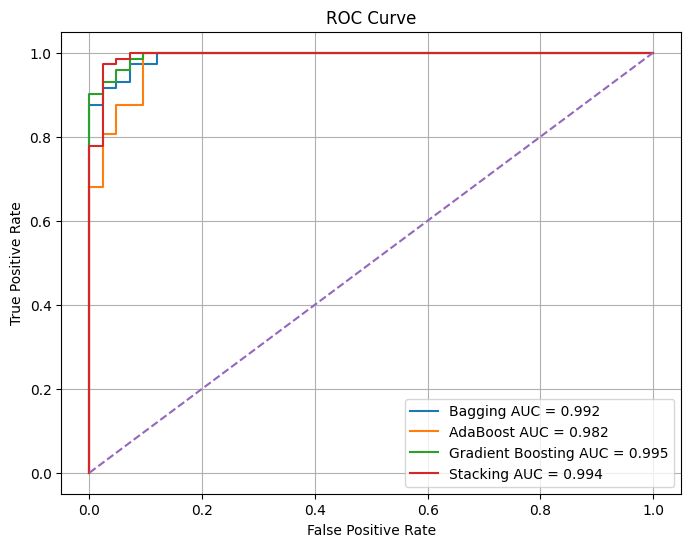

In [ ]:
plt.figure(figsize=(8,6))

for name, model in models.items():
    prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)

    plt.plot(fpr, tpr, label=name + " AUC = " + str(round(auc, 3)))

plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()